In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/3RDYEAR/CS346/cvae-face-generation')
sys.path.append('/content/drive/MyDrive/3RDYEAR/CS346/cvae-face-generation')

import torch
print(f"gpu available: {torch.cuda.is_available()}")
print(f"device: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
gpu available: True
device: Tesla T4


In [4]:
import json, os

kaggle_creds = {"username": "hermoinezozobrado", "key": "KGAT_adf6c2a3513d76c727af2f5d9d56547b"}
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

!kaggle datasets download -d jessicali9530/celeba-dataset \
  -p /content/celeba/ --unzip

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
Resuming from 488636416 bytes (939114376 bytes left)...
100% 1.33G/1.33G [00:12<00:00, 72.5MB/s]



In [5]:
from src.dataset import get_loaders

train_loader, test_loader = get_loaders('/content/celeba', batch_size=64)
print(f"train batches: {len(train_loader)}")

train batches: 2532


In [6]:
from src.cvae import CVAE, count_params

model = CVAE(latent_dim=128, n_attrs=6)
count_params(model)

total params:     3,011,011
trainable params: 3,011,011


In [7]:
import torch

dummy_imgs = torch.randn(4, 3, 64, 64)
dummy_attrs = torch.randint(0, 2, (4, 6)).float()

x_hat, mu, log_var = model(dummy_imgs, dummy_attrs)
print(f"input:   {dummy_imgs.shape}")
print(f"output:  {x_hat.shape}")
print(f"mu:      {mu.shape}")
print(f"log_var: {log_var.shape}")

loss, recon, kl = model.elbo_loss(dummy_imgs, x_hat, mu, log_var)
print(f"loss: {loss.item():.4f} | recon: {recon.item():.4f} | kl: {kl.item():.4f}")
print("forward pass ok")

input:   torch.Size([4, 3, 64, 64])
output:  torch.Size([4, 3, 64, 64])
mu:      torch.Size([4, 128])
log_var: torch.Size([4, 128])
loss: 1.0018 | recon: 1.0015 | kl: 0.0002
forward pass ok


In [8]:
from src.train import train_cvae

history = train_cvae(model, train_loader, epochs=30, lr=1e-3, beta=1.0)

training on: cuda
epochs: 30 | lr: 0.001 | beta: 1.0

epoch 001/30 | loss: 0.1906 | recon: 0.1527 | kl: 0.0379
epoch 005/30 | loss: 0.1729 | recon: 0.1302 | kl: 0.0426
epoch 010/30 | loss: 0.1716 | recon: 0.1288 | kl: 0.0428
epoch 015/30 | loss: 0.1711 | recon: 0.1282 | kl: 0.0429
epoch 020/30 | loss: 0.1708 | recon: 0.1277 | kl: 0.0430
epoch 025/30 | loss: 0.1706 | recon: 0.1275 | kl: 0.0431
epoch 030/30 | loss: 0.1705 | recon: 0.1274 | kl: 0.0430

training complete. best loss: 0.170469


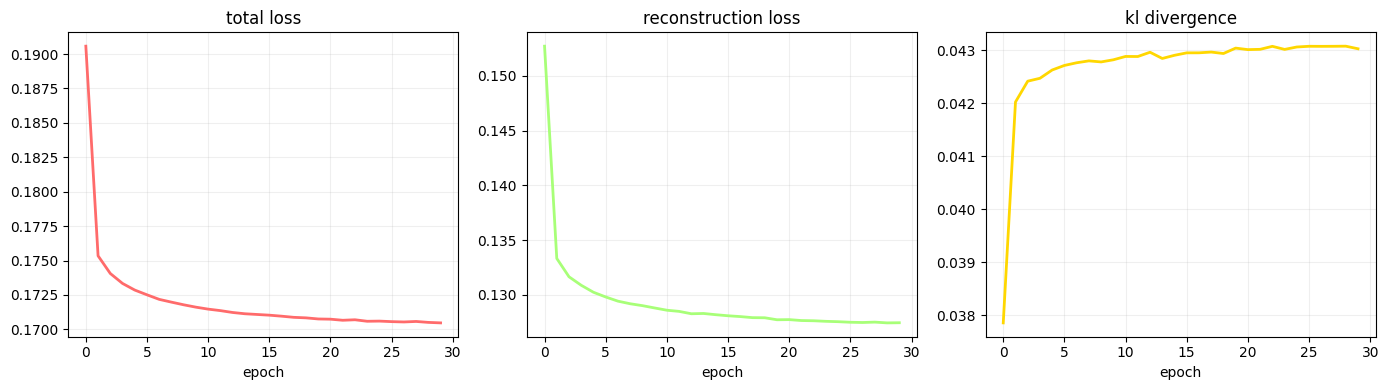

In [9]:
from src.visualize import plot_loss_curves
import os

os.makedirs('results/figures', exist_ok=True)
plot_loss_curves(history, save_path='results/figures/cvae_loss.png')

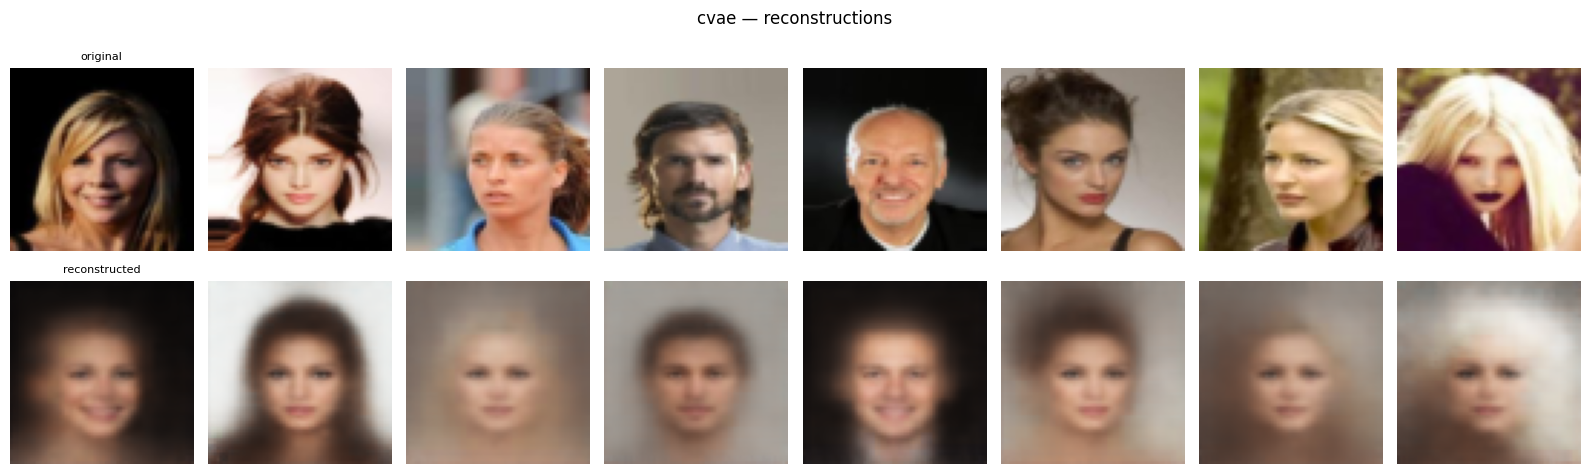

In [10]:
from src.visualize import plot_reconstructions

plot_reconstructions(model, test_loader, n=8,
                     save_path='results/figures/cvae_reconstructions.png')

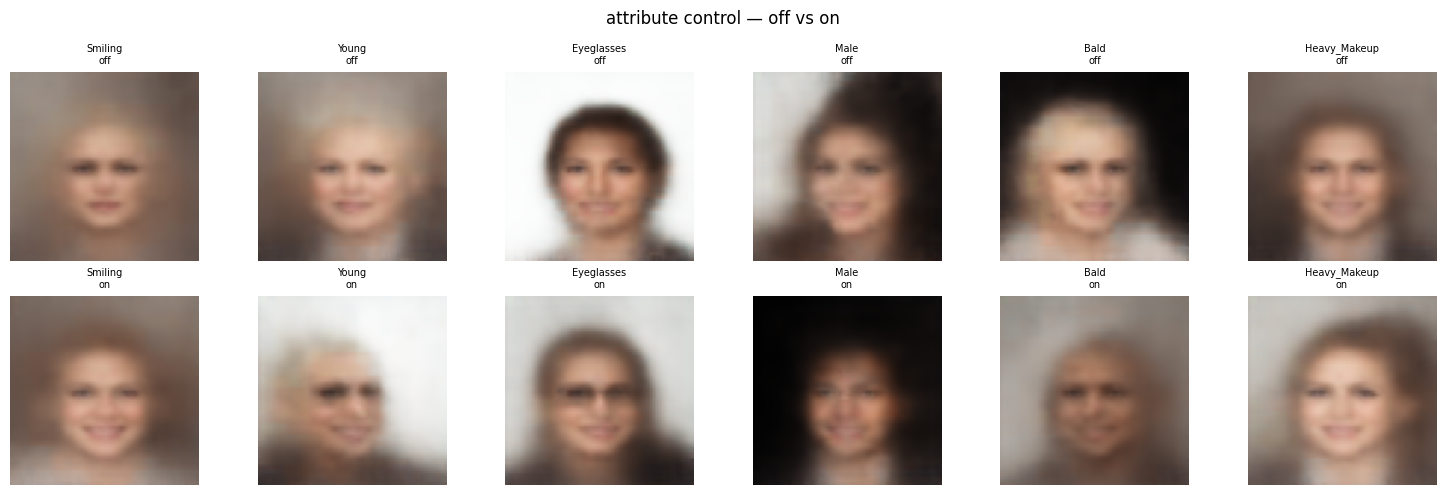

In [11]:
import torch
from src.visualize import plot_attribute_generation

# neutral base — all attributes at 0.5
base_attrs = torch.tensor([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]])
plot_attribute_generation(model, base_attrs, device=torch.device('cuda'),
                          save_path='results/figures/cvae_attributes.png')

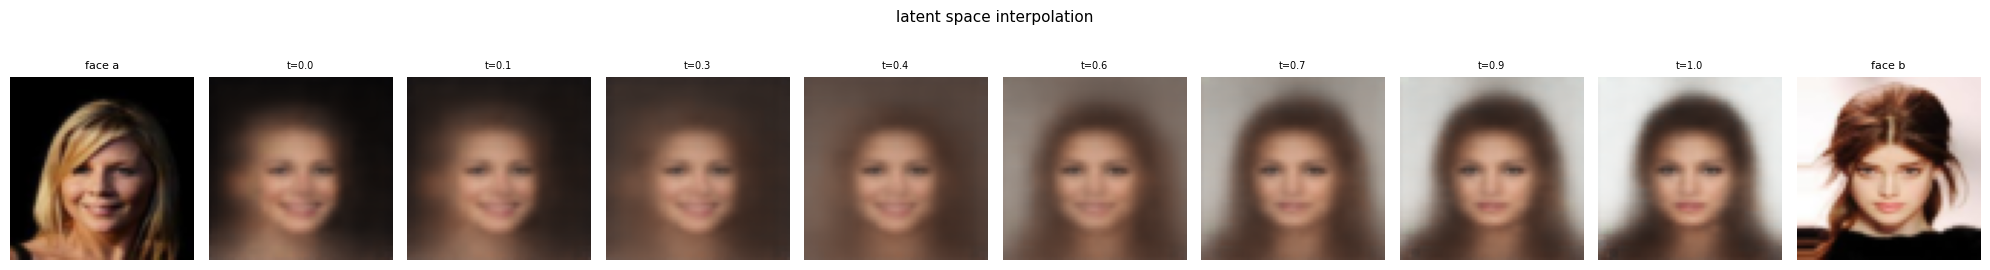

In [12]:
from src.visualize import plot_interpolation

plot_interpolation(model, test_loader, device=torch.device('cuda'),
                   save_path='results/figures/cvae_interpolation.png')

In [13]:
exec(open('demo/app.py').read())

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f14d9060687cb92045.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
